In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

SRC = Path("..") / "src"
sys.path.insert(0, str(SRC))

import synthetic_cfd as sc
import pinn_inverse_viscosity as piv
from plot_utils import apply_plot_style, MU_SB, DEG_SB
from json_utils import json_convert, json_deconvert

apply_plot_style()

np.random.seed(0)

In [3]:
RESULTS_DIR = Path("..") / "results" / "stage0_inverse_viscosity_demo"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path("..") / "data" / "processed"

DATASET_CHECK_PATH = RESULTS_DIR / "dataset_check.json"
CHECKPOINT_PATH = RESULTS_DIR / "main_run_checkpoint.pt"
HISTORY_PATH = RESULTS_DIR / "main_run_history.json"
NOISE_SWEEP_PATH = RESULTS_DIR / "noise_sweep.json"
SPARSITY_SWEEP_PATH = RESULTS_DIR / "sparsity_sweep.json"

FORCE_RETRAIN = False
RESUME_TRAINING = True

## Fake CFD: 2D Taylor-Green vortex

In [4]:
RHO = 1.0
MU_TRUE = 0.05
NOISE_STD = 0.0

T_RANGE = (0.0, 1.0)

dataset = sc.sample_synthetic_dataset(
    n_samples=3000,
    mu=MU_TRUE,
    rho=RHO,
    t_range=T_RANGE,
    noise_std=NOISE_STD,
    seed=0,
)

sc.save_dataset(dataset, DATA_DIR / "stage0_demo_dataset.npz")

print({k: v.shape if hasattr(v, "shape") else v for k, v in dataset.items()})

{'X': (3000, 4), 'u': (3000, 1), 'v': (3000, 1), 'w': (3000, 1), 'p': (3000, 1), 'mu_true': 0.05, 'rho': 1.0}


### Plot/Check

In [ ]:
CHECK_T_SNAPSHOTS = [0.0, 0.5, 1.0]
CHECK_T_TOL = 0.05

if DATASET_CHECK_PATH.exists() and not FORCE_RETRAIN:
    print(f"Found cached dataset-check data, skipping recompute: {DATASET_CHECK_PATH}")
else:
    dataset_for_check = sc.load_dataset(DATA_DIR / "stage0_demo_dataset.npz")
    mu_true_for_check = float(dataset_for_check["mu_true"])
    rho_for_check = float(dataset_for_check["rho"])

    x_lin = np.linspace(0, 2 * np.pi, 60)
    y_lin = np.linspace(0, 2 * np.pi, 60)
    xg_check, yg_check = np.meshgrid(x_lin, y_lin)
    zg_check = np.zeros_like(xg_check)

    X_all, u_all = dataset_for_check["X"], dataset_for_check["u"][:, 0]
    check_data = {
        "mu_true": mu_true_for_check,
        "rho": rho_for_check,
        "x_lin": x_lin,
        "y_lin": y_lin,
        "t_snapshots": CHECK_T_SNAPSHOTS,
        "exact_u": [],
        "sample_x": [],
        "sample_y": [],
        "sample_u": [],
    }
    for t_snap in CHECK_T_SNAPSHOTS:
        u_exact, _, _, _ = sc.taylor_green_fields(
            xg_check, yg_check, zg_check, np.full_like(xg_check, t_snap), mu_true_for_check, rho_for_check
        )
        check_data["exact_u"].append(u_exact)

        mask = np.abs(X_all[:, 3] - t_snap) <= CHECK_T_TOL
        check_data["sample_x"].append(X_all[mask, 0])
        check_data["sample_y"].append(X_all[mask, 1])
        check_data["sample_u"].append(u_all[mask])

    with open(DATASET_CHECK_PATH, "w", encoding="utf-8") as f:
        json.dump(check_data, f, default=json_convert, ensure_ascii=False, indent=2)
    print(f"Saved dataset-check data to: {DATASET_CHECK_PATH}")

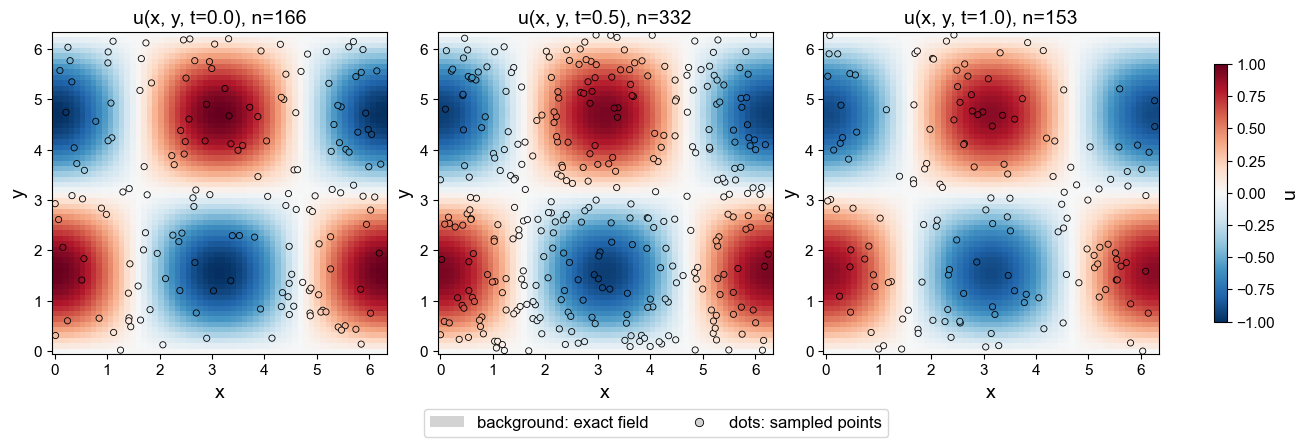

In [10]:
with open(DATASET_CHECK_PATH, encoding="utf-8") as f:
    check_data = json.load(f, object_hook=json_deconvert)

xg_check, yg_check = np.meshgrid(check_data["x_lin"], check_data["y_lin"])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, t_snap, u_exact, sx, sy, su in zip(
    axes,
    check_data["t_snapshots"],
    check_data["exact_u"],
    check_data["sample_x"],
    check_data["sample_y"],
    check_data["sample_u"],
):
    im = ax.pcolormesh(xg_check, yg_check, u_exact, shading="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    ax.scatter(sx, sy, c=su, cmap="RdBu_r", vmin=-1, vmax=1, s=20, edgecolors="k", linewidths=0.6)
    ax.set_title(f"u(x, y, t={t_snap}), n={len(sx)}")
    ax.set_xlabel("x"); ax.set_ylabel("y")

legend_handles = [
    Patch(facecolor="lightgray", edgecolor="none", label="background: exact field"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="lightgray",
           markeredgecolor="k", markeredgewidth=0.6, markersize=6, label="dots: sampled points"),
]
fig.colorbar(im, ax=axes, shrink=0.8, label="u")
fig.legend(handles=legend_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.1))
plt.show()

## Train PINN, inverse mu

In [11]:
MU_INIT = 1.0

result = piv.run_inverse_viscosity(
    dataset,
    rho=RHO,
    mu_init=MU_INIT,
    z_range=(0.0, 1.0),
    t_range=T_RANGE,
    num_domain=4000,
    adam_iterations=15000,
    adam_lr=1e-3,
    log_every=500,
    checkpoint_path=CHECKPOINT_PATH,
    resume=RESUME_TRAINING,
)

with open(HISTORY_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {"history": result["history"], "mu_recovered": result["mu_recovered"], "mu_true": MU_TRUE},
        f, default=json_convert, ensure_ascii=False, indent=2,
    )

print(f"mu_true      = {MU_TRUE}")
print(f"mu_recovered = {result['mu_recovered']:.5f}")
print(f"relative error = {abs(result['mu_recovered'] - MU_TRUE) / MU_TRUE:.2%}")

Training on device: cuda
[adam] iter      0  loss=1.3850e+00  data=1.2186e+00  pde=1.6637e-01  mu=0.99900
[adam] iter    500  loss=9.3670e-02  data=6.9379e-02  pde=2.4290e-02  mu=0.44269
[adam] iter   1000  loss=1.5001e-02  data=9.7161e-03  pde=5.2850e-03  mu=0.09331
[adam] iter   1500  loss=6.5122e-03  data=3.6948e-03  pde=2.8174e-03  mu=0.04971
[adam] iter   2000  loss=3.6837e-03  data=1.8517e-03  pde=1.8321e-03  mu=0.03672
[adam] iter   2500  loss=2.4305e-03  data=1.1852e-03  pde=1.2453e-03  mu=0.03268
[adam] iter   3000  loss=1.8043e-03  data=8.6679e-04  pde=9.3750e-04  mu=0.03255
[adam] iter   3500  loss=1.1722e-03  data=5.2417e-04  pde=6.4800e-04  mu=0.03277
[adam] iter   4000  loss=7.7042e-04  data=3.0916e-04  pde=4.6126e-04  mu=0.03486
[adam] iter   4500  loss=5.9766e-04  data=2.2996e-04  pde=3.6771e-04  mu=0.03616
[adam] iter   5000  loss=4.7912e-04  data=1.7990e-04  pde=2.9922e-04  mu=0.03798
[adam] iter   5500  loss=4.5346e-04  data=1.7860e-04  pde=2.7485e-04  mu=0.03900
[ad

### Loss, mu convergence

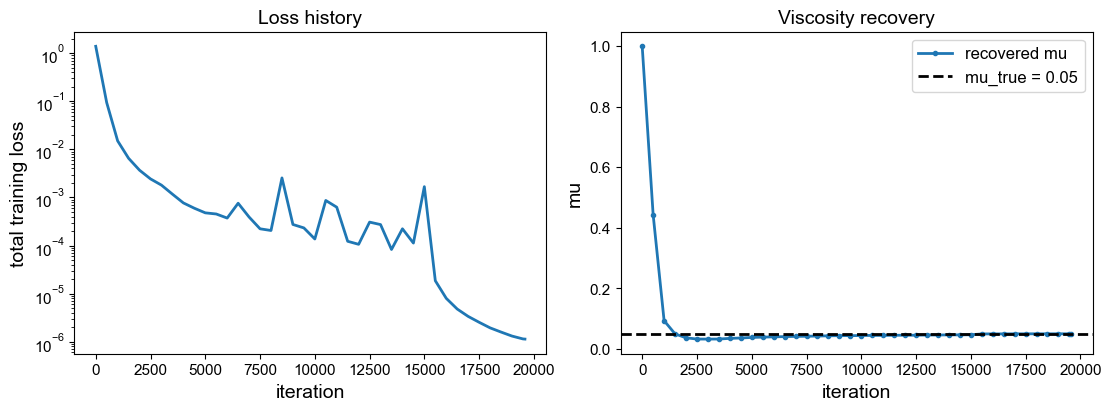

In [12]:
with open(HISTORY_PATH, encoding="utf-8") as f:
    history_data = json.load(f, object_hook=json_deconvert)
history = history_data["history"]
mu_true_for_plot = history_data["mu_true"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax1.semilogy(history["iteration"], history["loss"])
ax1.set_xlabel("iteration"); ax1.set_ylabel("total training loss"); ax1.set_title("Loss history")

ax2.plot(history["iteration"], history["mu"], marker="o", ms=3, label="recovered mu")
ax2.axhline(mu_true_for_plot, color="k", ls="--", label=f"mu_true = {mu_true_for_plot}")
ax2.set_xlabel("iteration"); ax2.set_ylabel("mu"); ax2.set_title("Viscosity recovery"); ax2.legend()

plt.show()

### Reconstruct

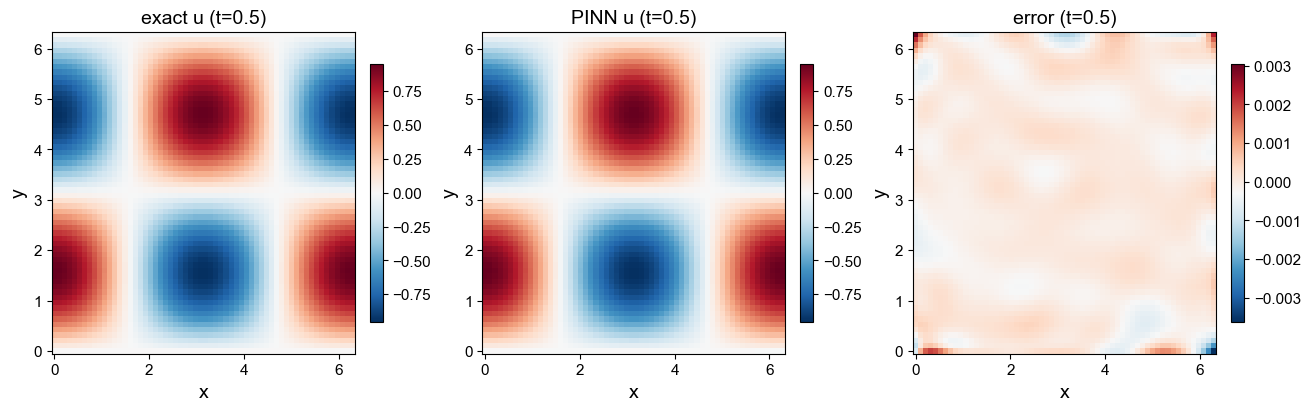

In [13]:
with open(DATASET_CHECK_PATH, encoding="utf-8") as f:
    check_data = json.load(f, object_hook=json_deconvert)

t_snap = 0.5
snap_idx = check_data["t_snapshots"].index(t_snap)
xg, yg = np.meshgrid(check_data["x_lin"], check_data["y_lin"])
u_true = check_data["exact_u"][snap_idx]

model, mu_recovered = piv.load_model(CHECKPOINT_PATH)
grid_X = np.column_stack([xg.ravel(), yg.ravel(), np.zeros(xg.size), np.full(xg.size, t_snap)])
u_pred = model.predict(grid_X)[:, 0].reshape(xg.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, field, title in zip(
    axes, [u_true, u_pred, u_pred - u_true], ["exact u", "PINN u", "error"]
):
    im = ax.pcolormesh(xg, yg, field, shading="auto", cmap="RdBu_r")
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"{title} (t={t_snap})")
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.show()

## Noise sensitivity

In [14]:
import contextlib
import io


def run_one(n_samples, noise_std, seed, adam_iterations, lbfgs_iterations, mu_init=1.0):
    dataset = sc.sample_synthetic_dataset(
        n_samples=n_samples,
        mu=MU_TRUE,
        rho=RHO,
        t_range=T_RANGE,
        noise_std=noise_std,
        seed=seed,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        result = piv.run_inverse_viscosity(
            dataset,
            rho=RHO,
            mu_init=mu_init,
            z_range=(0.0, 1.0),
            t_range=T_RANGE,
            num_domain=4000,
            adam_iterations=adam_iterations,
            adam_lr=1e-3,
            log_every=adam_iterations,
            run_lbfgs=True,
            lbfgs_iterations=lbfgs_iterations,
            seed=seed,
        )
    mu_recovered = result["mu_recovered"]
    rel_error = abs(mu_recovered - MU_TRUE) / MU_TRUE
    return mu_recovered, rel_error


def run_sweep(param_name, param_values, n_repeats, **fixed_kwargs):
    records = {"param": [], "seed": [], "mu_recovered": [], "rel_error": []}
    for value in param_values:
        for seed in range(n_repeats):
            kwargs = dict(fixed_kwargs)
            kwargs[param_name] = value
            mu_recovered, rel_error = run_one(seed=seed, **kwargs)
            records["param"].append(value)
            records["seed"].append(seed)
            records["mu_recovered"].append(mu_recovered)
            records["rel_error"].append(rel_error)
            print(
                f"{param_name}={value!r:>8}  seed={seed}  "
                f"mu_recovered={mu_recovered:.5f}  rel_error={rel_error:.2%}"
            )
    return {k: np.array(v) for k, v in records.items()}


def summarize_sweep(records, param_values):
    means, stds, rel_means, rel_stds = [], [], [], []
    for value in param_values:
        mask = records["param"] == value
        means.append(records["mu_recovered"][mask].mean())
        stds.append(records["mu_recovered"][mask].std())
        rel_means.append(records["rel_error"][mask].mean())
        rel_stds.append(records["rel_error"][mask].std())
    return map(np.array, (means, stds, rel_means, rel_stds))

In [ ]:
NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1]
N_REPEATS = 3
SWEEP_ADAM_ITERS = 6000
SWEEP_LBFGS_ITERS = 5000

if NOISE_SWEEP_PATH.exists() and not FORCE_RETRAIN:
    print(f"Found cached noise-sweep results, skipping retrain: {NOISE_SWEEP_PATH}")
else:
    noise_records = run_sweep(
        "noise_std",
        NOISE_LEVELS,
        n_repeats=N_REPEATS,
        n_samples=3000,
        adam_iterations=SWEEP_ADAM_ITERS,
        lbfgs_iterations=SWEEP_LBFGS_ITERS,
    )
    with open(NOISE_SWEEP_PATH, "w", encoding="utf-8") as f:
        json.dump(
            {"records": noise_records, "mu_true": MU_TRUE},
            f, default=json_convert, ensure_ascii=False, indent=2,
        )
    print(f"Saved noise sweep results to: {NOISE_SWEEP_PATH}")

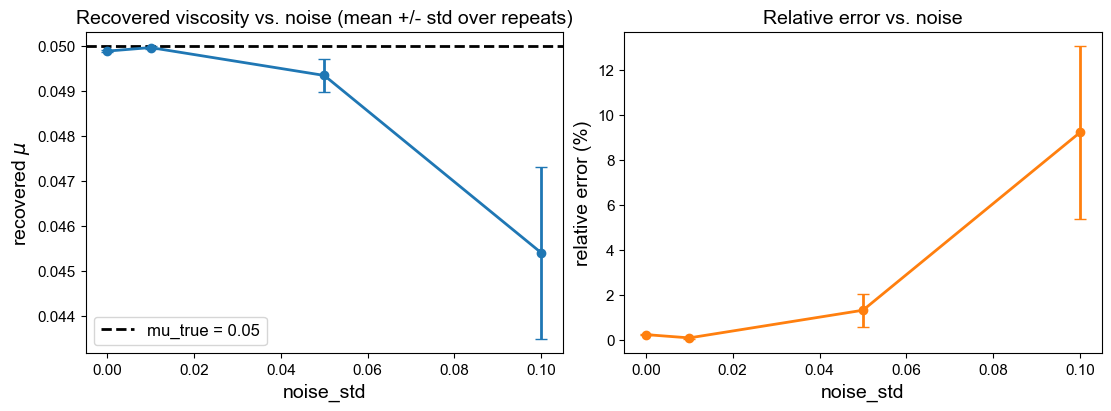

In [16]:
with open(NOISE_SWEEP_PATH, encoding="utf-8") as f:
    noise_data = json.load(f, object_hook=json_deconvert)
noise_records = noise_data["records"]
mu_true_for_plot = noise_data["mu_true"]
noise_levels = sorted(set(noise_records["param"].tolist()))

noise_mean, noise_std_of_mu, noise_rel_mean, noise_rel_std = summarize_sweep(noise_records, noise_levels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax1.errorbar(noise_levels, noise_mean, yerr=noise_std_of_mu, marker="o", capsize=4)
ax1.axhline(mu_true_for_plot, color="k", ls="--", label=f"mu_true = {mu_true_for_plot}")
ax1.set_xlabel("noise_std"); ax1.set_ylabel(r"recovered $\mu$")
ax1.set_title("Recovered viscosity vs. noise (mean +/- std over repeats)"); ax1.legend()

ax2.errorbar(noise_levels, noise_rel_mean * 100, yerr=noise_rel_std * 100, marker="o", capsize=4, color="C1")
ax2.set_xlabel("noise_std"); ax2.set_ylabel("relative error (%)")
ax2.set_title("Relative error vs. noise")

plt.show()

## Sample number sensitivity

In [ ]:
SAMPLE_COUNTS = [3000, 1000, 300, 100, 30]

if SPARSITY_SWEEP_PATH.exists() and not FORCE_RETRAIN:
    print(f"Found cached sparsity-sweep results, skipping retrain: {SPARSITY_SWEEP_PATH}")
else:
    sparsity_records = run_sweep(
        "n_samples",
        SAMPLE_COUNTS,
        n_repeats=N_REPEATS,
        noise_std=0.0,
        adam_iterations=SWEEP_ADAM_ITERS,
        lbfgs_iterations=SWEEP_LBFGS_ITERS,
    )
    with open(SPARSITY_SWEEP_PATH, "w", encoding="utf-8") as f:
        json.dump(
            {"records": sparsity_records, "mu_true": MU_TRUE},
            f, default=json_convert, ensure_ascii=False, indent=2,
        )
    print(f"Saved sparsity sweep results to: {SPARSITY_SWEEP_PATH}")

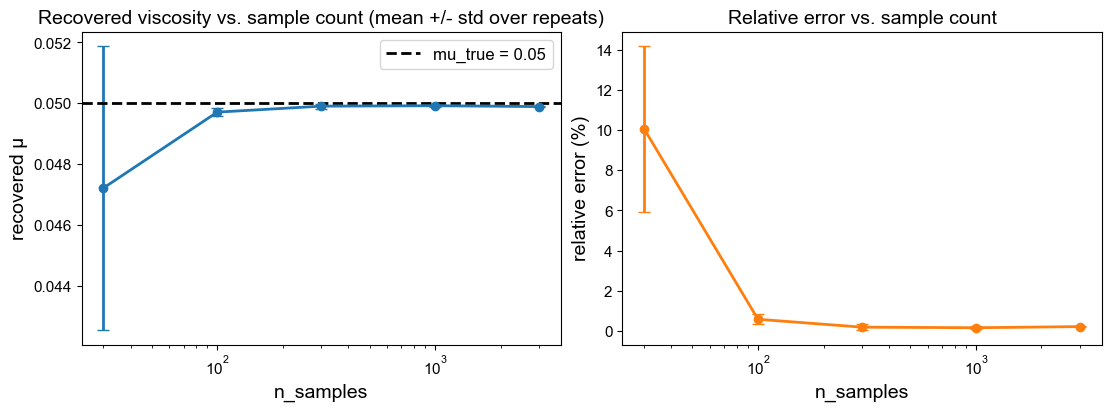

In [18]:
with open(SPARSITY_SWEEP_PATH, encoding="utf-8") as f:
    sparsity_data = json.load(f, object_hook=json_deconvert)
sparsity_records = sparsity_data["records"]
mu_true_for_plot = sparsity_data["mu_true"]
sample_counts = sorted(set(sparsity_records["param"].tolist()))

sparsity_mean, sparsity_std_of_mu, sparsity_rel_mean, sparsity_rel_std = summarize_sweep(
    sparsity_records, sample_counts
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax1.errorbar(sample_counts, sparsity_mean, yerr=sparsity_std_of_mu, marker="o", capsize=4)
ax1.axhline(mu_true_for_plot, color="k", ls="--", label=f"mu_true = {mu_true_for_plot}")
ax1.set_xscale("log")
ax1.set_xlabel("n_samples"); ax1.set_ylabel(f"recovered {MU_SB}")
ax1.set_title("Recovered viscosity vs. sample count (mean +/- std over repeats)"); ax1.legend()

ax2.errorbar(sample_counts, sparsity_rel_mean * 100, yerr=sparsity_rel_std * 100, marker="o", capsize=4, color="C1")
ax2.set_xscale("log")
ax2.set_xlabel("n_samples"); ax2.set_ylabel("relative error (%)")
ax2.set_title("Relative error vs. sample count")

plt.show()